# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [58]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [59]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [60]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [61]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [62]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


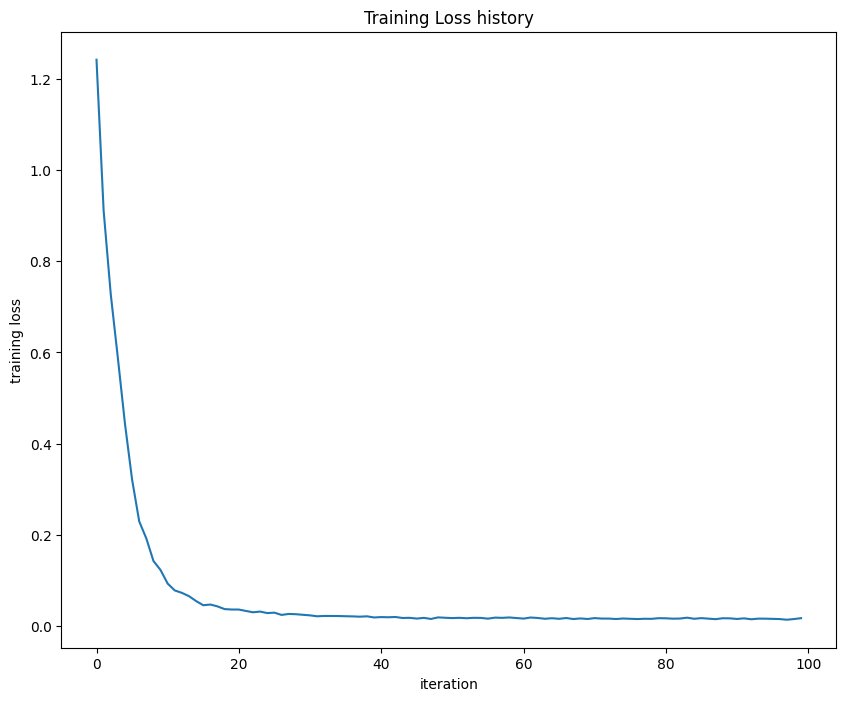

In [63]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [64]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data
y = digits.target
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

input_size = X_train.shape[1]
hidden_size = 50
num_classes = 10

net = TwoLayerNet(input_size, hidden_size, num_classes)
stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302594
iteration 100 / 1000: loss 2.302597
iteration 200 / 1000: loss 2.302589
iteration 300 / 1000: loss 2.302586
iteration 400 / 1000: loss 2.302600
iteration 500 / 1000: loss 2.302592
iteration 600 / 1000: loss 2.302593
iteration 700 / 1000: loss 2.302588
iteration 800 / 1000: loss 2.302592
iteration 900 / 1000: loss 2.302593
Validation accuracy:  0.10277777777777777


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

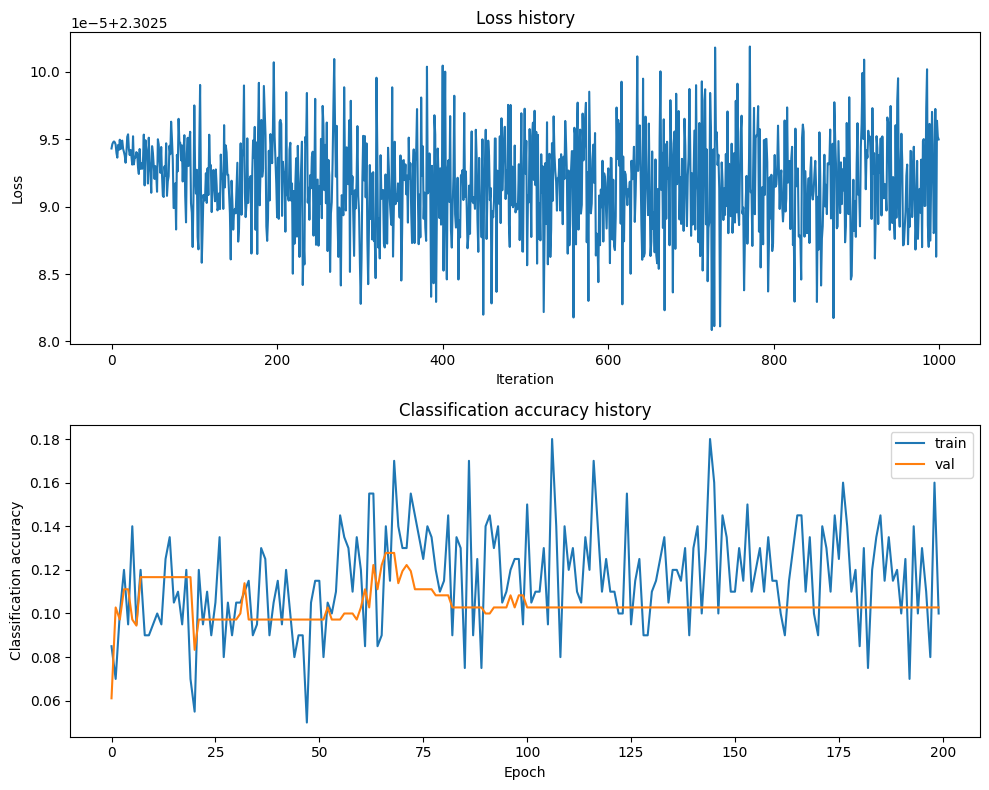

In [65]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.tight_layout()
plt.show()

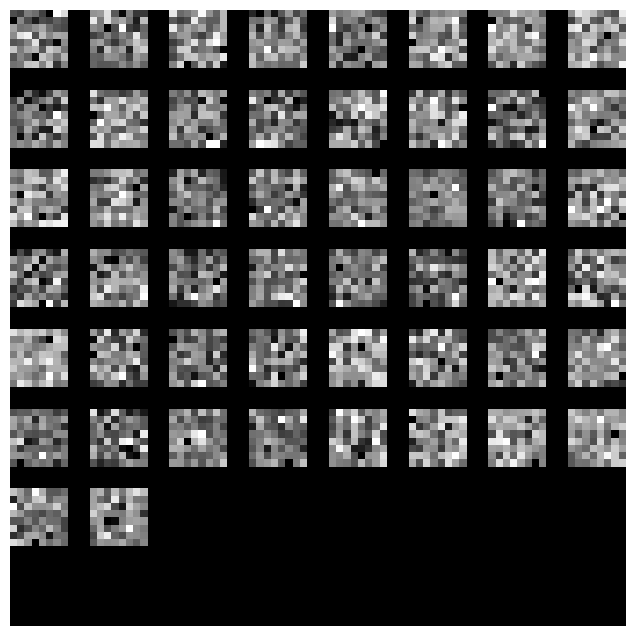

In [66]:
from scripts.vis_utils import visualize_grid
import matplotlib.pyplot as plt

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(8, 8, 1, -1).transpose(3, 0, 1, 2)
    grid = visualize_grid(W1, padding=3).astype('uint8')
    
    if grid.shape[-1] == 1:
        grid = grid.squeeze(axis=-1)
        
    plt.imshow(grid, cmap='gray')
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

## Эксперименты

### Шаг 1: gridsearch

In [67]:
np.random.seed(42)
learning_rates = [0.1, 0.01, 0.001]
regularizations = [0.0, 0.001, 0.01, 0.1]

best_val_acc = -1
best_net = None
best_params = {}
best_stats = {}

input_size = X_train.shape[1]
hidden_size = 100
num_classes = 10

for lr in learning_rates:
    for reg in regularizations:
        print(f"Learning with lr={lr}, reg={reg}")
        net = TwoLayerNet(input_size, hidden_size, num_classes)
        stats = net.train(X_train, y_train, X_val, y_val,
                    num_iters=2000, batch_size=200,
                    learning_rate=lr, learning_rate_decay=0.95,
                    reg=reg, verbose=False)

        val_acc = (net.predict(X_val) == y_val).mean()
        print(f"Val accuracy: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_net = net
            best_stats = stats
            best_params = {'lr': lr, 'reg': reg}

print(f"Best val accuracy: {best_val_acc:.4f}")
print(f"Best params: {best_params}")

Learning with lr=0.1, reg=0.0
Val accuracy: 0.9639
Learning with lr=0.1, reg=0.001
Val accuracy: 0.9639
Learning with lr=0.1, reg=0.01
Val accuracy: 0.9583
Learning with lr=0.1, reg=0.1
Val accuracy: 0.9472
Learning with lr=0.01, reg=0.0
Val accuracy: 0.1944
Learning with lr=0.01, reg=0.001
Val accuracy: 0.1639
Learning with lr=0.01, reg=0.01
Val accuracy: 0.0944
Learning with lr=0.01, reg=0.1
Val accuracy: 0.0806
Learning with lr=0.001, reg=0.0
Val accuracy: 0.0806
Learning with lr=0.001, reg=0.001
Val accuracy: 0.0806
Learning with lr=0.001, reg=0.01
Val accuracy: 0.0806
Learning with lr=0.001, reg=0.1
Val accuracy: 0.0806
Best val accuracy: 0.9639
Best params: {'lr': 0.1, 'reg': 0.0}


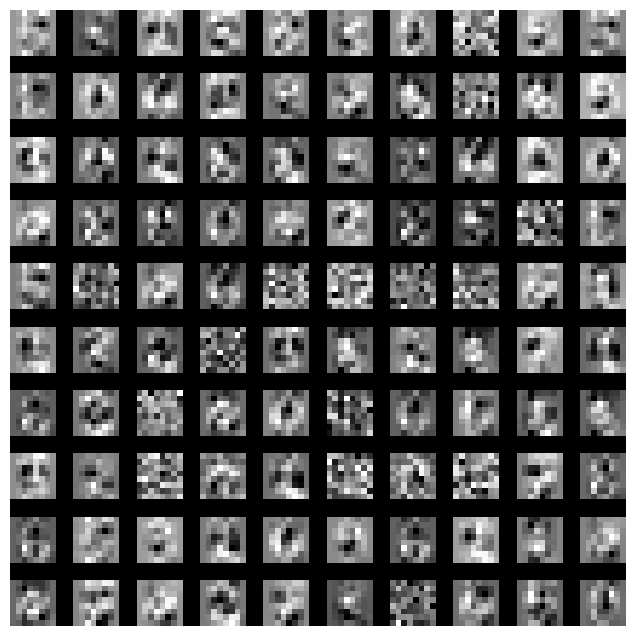

In [68]:
from scripts.vis_utils import visualize_grid
import matplotlib.pyplot as plt

def show_net_weights(net):
    W1 = best_net.params['W1']
    W1 = W1.reshape(8, 8, 1, -1).transpose(3, 0, 1, 2)
    grid = visualize_grid(W1, padding=3).astype('uint8')
    
    if grid.shape[-1] == 1:
        grid = grid.squeeze(axis=-1)
        
    plt.imshow(grid, cmap='gray')
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

### Шаг 2: PCA

In [72]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=40, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

input_size = X_train_pca.shape[1]
num_classes = 10

np.random.seed(42)
net = TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

best_stats = net.train(X_train_pca, y_train, X_val_pca, y_val,
            num_iters=2000, batch_size=200,
            learning_rate=best_params["lr"], learning_rate_decay=0.95,
            reg=best_params["reg"], verbose=True)

val_acc = (net.predict(X_val_pca) == y_val).mean()
print('Validation accuracy with PCA:', val_acc)

iteration 0 / 2000: loss 3.687779
iteration 100 / 2000: loss 0.051888
iteration 200 / 2000: loss 0.019223
iteration 300 / 2000: loss 0.039479
iteration 400 / 2000: loss 0.026937
iteration 500 / 2000: loss 0.029097
iteration 600 / 2000: loss 0.027618
iteration 700 / 2000: loss 0.032302
iteration 800 / 2000: loss 0.023098
iteration 900 / 2000: loss 0.037814
iteration 1000 / 2000: loss 0.017352
iteration 1100 / 2000: loss 0.024319
iteration 1200 / 2000: loss 0.025999
iteration 1300 / 2000: loss 0.023300
iteration 1400 / 2000: loss 0.015703
iteration 1500 / 2000: loss 0.035014
iteration 1600 / 2000: loss 0.027803
iteration 1700 / 2000: loss 0.030467
iteration 1800 / 2000: loss 0.023316
iteration 1900 / 2000: loss 0.044257
Validation accuracy with PCA: 0.975


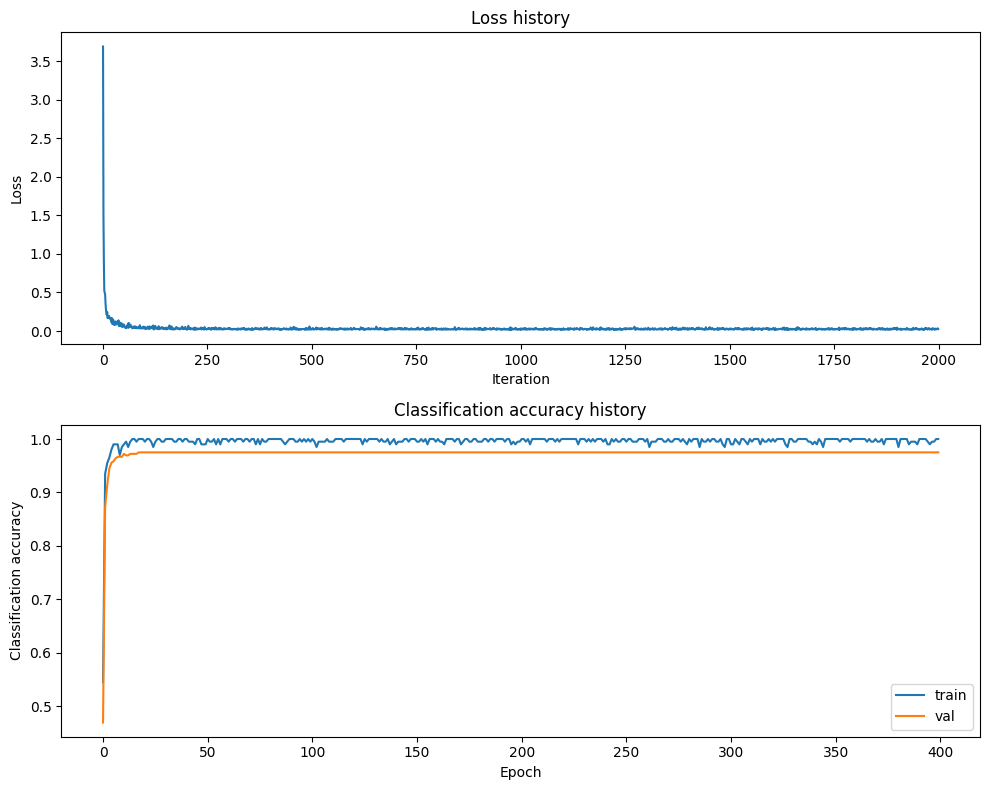

In [70]:
plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(best_stats['train_acc_history'], label='train')
plt.plot(best_stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
test_acc = (net.predict(X_test_pca) == y_test).mean()
print(f'Final test accuracy: {test_acc:.4f}')

Final test accuracy: 0.9722


Сделайте выводы по результатам работы. 

 В ходе лабораторной работы была успешно реализована с нуля двухслойная полносвязная нейронная сеть для решения задачи классификации. Корректность аналитического вычисления функции потерь и градиентов была подтверждена с помощью проверки численным градиентом.   
 При первичном обучении на наборе данных digits с параметрами по умолчанию сеть показала низкую точность (около 10.2%). Для максимизации обобщающей способности были проведены эксперименты по настройке гиперпараметров: скорости обучения, силы L2-регуляризации и применено снижение размерности входных данных с помощью метода главных компонент до 40 компонент.Это позволило улучшить результаты сети: Максимальная точность классификации на валидационном наборе достигла 97.5%.  
 Итоговая точность лучшей модели на отложенном тестовом наборе составила 97.22%. Минимальная разница между результатами на валидационной и тестовой выборках доказывает, что модель избежала переобучения, успешно выявила скрытые закономерности в данных и обладает высокой обобщающей способностью при работе с новыми изображениями.